# Curvilinear-grid NetCDF files

Grids with 2-D latitude/longitude coordinate arrays (no single affine transform). These support inspection, plotting (via pcolormesh), retrieval, and variable mutation, and polygon crop (by masking on the 2-D coordinates — see below).

In [1]:
%matplotlib inline
import tempfile
from pathlib import Path

import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon

from pyramids.feature import FeatureCollection
from pyramids.netcdf import CoordinateSpec, GeoReference, NetCDF

DATA = Path('../../../../examples/data/netcdf/samples')

## `cf__8v__1d3-2d3-3d1-4d1__curv-stag.nc`

ROMS ocean model output on a curvilinear, staggered (Arakawa-C) grid.

**Open the file and inspect the container**

In [2]:
nc = NetCDF.read_file(DATA / 'cf__8v__1d3-2d3-3d1-4d1__curv-stag.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\cf__8v__1d3-2d3-3d1-4d1__curv-stag.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [3]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (4):
    eta_rho              size=191
    ocean_time           size=2
    s_rho                size=6
    xi_rho               size=371
  Variables (8):
    Cs_r dims=('/s_rho',) shape=(6,) dtype=float64
    h dims=('/eta_rho', '/xi_rho') shape=(191, 371) dtype=float64 unit='meter'
    lat_rho dims=('/eta_rho', '/xi_rho') shape=(191, 371) dtype=float64 unit='degree_north'
    lon_rho dims=('/eta_rho', '/xi_rho') shape=(191, 371) dtype=float64 unit='degree_east'
    ocean_time dims=('/ocean_time',) shape=(2,) dtype=float64 unit='seconds since 1970-01-01'
    s_rho dims=('/s_rho',) shape=(6,) dtype=float64
    salt dims=('/ocean_time', '/s_rho', '/eta_rho', '/xi_rho') shape=(2, 6, 191, 371) dtype=float32
    zeta dims=('/ocean_time', '/eta_rho', '/xi_rho') shape=(2, 191, 371) dtype=float32 unit='meter'
  Global attributes: Conventions, file, format, type, title, ... (34 total)


C:\python-environments\pixi\envs\pyramids-gis-1740942553316771400\envs\docs\Lib\site-packages\osgeo\gdal.py:8299: RuntimeWarning: Cannot find variable corresponding to coordinate hc
  return _gdal.MDArray_GetCoordinateVariables(self, *args)
C:\python-environments\pixi\envs\pyramids-gis-1740942553316771400\envs\docs\Lib\site-packages\osgeo\gdal.py:8299: RuntimeWarning: Cannot find variable corresponding to coordinate Vtransform
  return _gdal.MDArray_GetCoordinateVariables(self, *args)


**Global attributes**

In [4]:
nc.global_attributes

{'Conventions': 'CF-1.4',
 'file': '../output_20yr_obc/2001/ocean_his_0015.nc',
 'format': 'netCDF-4/HDF5 file',
 'type': 'ROMS/TOMS history file',
 'title': 'TXLA ROMS hindcast run with dyes and oxygen',
 'rst_file': '../output_20yr_obc/2001/ocean_rst.nc',
 'his_base': '../output_20yr_obc/2001/ocean_his',
 'avg_base': '../output_20yr_obc/2001/ocean_avg',
 'dia_base': '../output_20yr_obc/2001/ocean_dia',
 'sta_file': 'ocean_sta.nc',
 'grd_file': '../inputs/grd/txla2_grd_v4_test_lcut_hglo_wtype.nc',
 'ini_file': '../output_20yr_obc/2000/ocean_rst.nc',
 'frc_file_01': '../inputs/2001/txla_bulk_ERAI_2001.nc',
 'frc_file_02': '../inputs/2001/txla_flx_ICOADS_AVHRR_SST_2001.nc, ../inputs/2002/txla_flx_ICOADS_AVHRR_SST_2002.nc',
 'bry_file_01': '../inputs/2001/txla2_bry_2001_glo_ReAna_v4_o2woa.nc, ../inputs/2002/txla2_bry_2002_glo_ReAna_v4_o2woa.nc',
 'clm_file_01': '../inputs/2001/txla2_clm_2001_01_glo_ReAna_v4_o2woa.nc, ../inputs/2001/txla2_clm_2001_02_glo_ReAna_v4_o2woa.nc, ../inputs/2001/

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

C:\python-environments\pixi\envs\pyramids-gis-1740942553316771400\envs\docs\Lib\site-packages\matplotlib\colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


<Axes: >

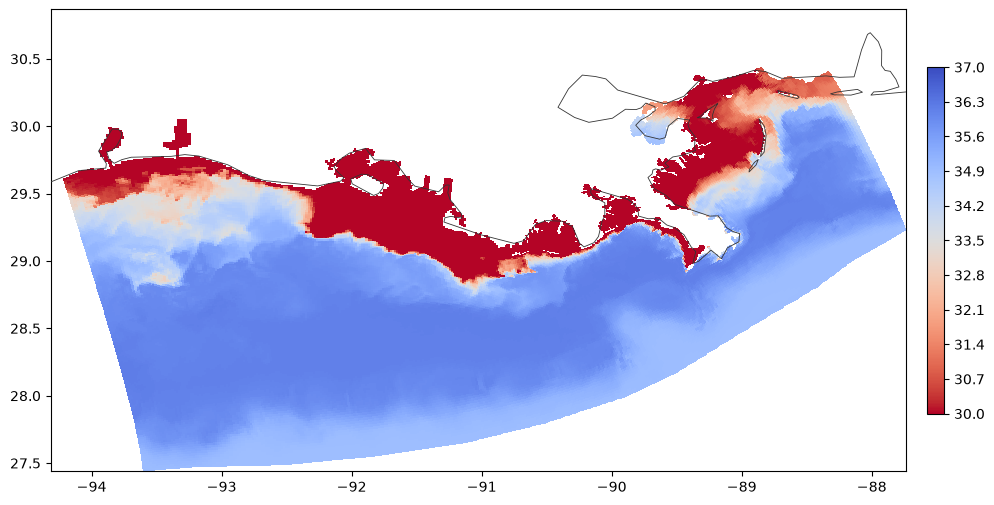

In [5]:
# clamp the colour scale to the open-ocean range: the coastal freshwater plumes
# pull the default min down to ~9 PSU, which flattens the offshore salinity
# structure into near-uniform blue
glyph = nc.plot(variable='salt', vmin=30, vmax=37)
# the glyph carries the variable's CRS (issue #630), so the Natural Earth coastline
# overlay lines up with this curvilinear lon/lat grid without restating crs=
glyph.add_features("coastline", "50m", zorder=5)

**Retrieve the underlying data**

In [6]:
var = nc.get_variable('salt')
data = var.read_array()
print('shape:', data.shape)
print(
    'min / mean / max:',
    float(np.nanmin(data)),
    float(np.nanmean(data)),
    float(np.nanmax(data)),
)

shape: (12, 191, 371)
min / mean / max: 6.549163818359375 inf 9.999999933815813e+36


C:\python-environments\pixi\envs\pyramids-gis-1740942553316771400\envs\docs\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


**Add a variable** — derive a 2-D field and append it as a new variable

In [7]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d,
    geo_ref=GeoReference(geo=(0.0, 1.0, 0.0, 0.0, 0.0, -1.0), epsg=var.epsg or 4326),
    variable_name='salt_slice0',
    path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'salt_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['Cs_r', 'h', 'lat_rho', 'lon_rho', 'salt', 'salt_slice0', 'zeta']


**Remove a variable**

In [8]:
nc.remove_variable('salt_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['Cs_r', 'h', 'lat_rho', 'lon_rho', 'salt', 'zeta']


**Crop with a polygon** — this grid is **curvilinear** (2-D `lat_rho`/`lon_rho`), so there is no single affine transform to clip against. `crop` therefore masks each cell whose centre falls outside the polygon to no-data and trims to the bounding window, **keeping the 2-D coordinates** so the result stays curvilinear and still plots on its real geometry.

cropped shape: (12, 191, 211)


<Axes: >

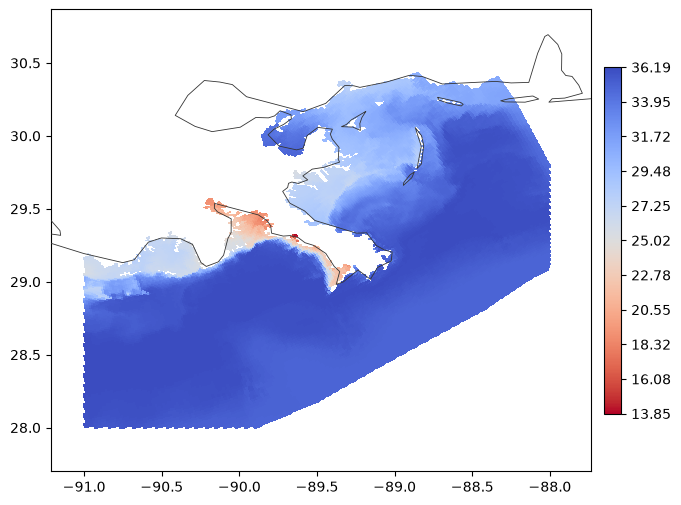

In [9]:
# a box over the eastern Gulf shelf (lon -91..-88, lat 28..30.5)
aoi = FeatureCollection(
    gpd.GeoDataFrame(
        geometry=[Polygon([(-91, 28), (-88, 28), (-88, 30.5), (-91, 30.5)])], crs=4326
    )
)
salt = nc.get_variable('salt')
cropped = salt.crop(aoi)
print('cropped shape:', cropped.shape)
glyph = cropped.plot()
# overlay the coastline so the cropped curvilinear patch is easy to place
glyph.add_features("coastline", "50m", zorder=5)

**Save the container to a new NetCDF file**

In [10]:
out = work / 'saved.nc'
nc.to_file(out)
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True


## `none__4v__1d1-2d2-3d1__curv.nc`

WRF/RASM air temperature on a curvilinear grid (2-D xc/yc coordinates).

**Open the file and inspect the container**

In [11]:
nc = NetCDF.read_file(DATA / 'none__4v__1d1-2d2-3d1__curv.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\none__4v__1d1-2d2-3d1__curv.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [12]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (3):
    time                 size=6
    x                    size=275
    y                    size=205
  Variables (4):
    Tair dims=('/time', '/y', '/x') shape=(6, 205, 275) dtype=float64 unit='C'
    time dims=('/time',) shape=(6,) dtype=float64 unit='days since 0001-01-01'
    xc dims=('/y', '/x') shape=(205, 275) dtype=float64 unit='degrees_east'
    yc dims=('/y', '/x') shape=(205, 275) dtype=float64 unit='degrees_north'
  Global attributes: title, institution, source, output_frequency, output_mode, ... (11 total)


**Global attributes**

In [13]:
nc.global_attributes

{'title': '/workspace/jhamman/processed/R1002RBRxaaa01a/lnd/temp/R1002RBRxaaa01a.vic.ha.1979-09-01.nc',
 'institution': 'U.W.',
 'source': 'RACM R1002RBRxaaa01a',
 'output_frequency': 'daily',
 'output_mode': 'averaged',
 'convention': 'CF-1.4',
 'references': 'Based on the initial model of Liang et al., 1994, JGR, 99, 14,415- 14,429.',
 'comment': 'Output from the Variable Infiltration Capacity (VIC) model.',
 'nco_openmp_thread_number': 1,
 'NCO': 'netCDF Operators version 4.7.9 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)',
 'history': 'Fri Aug  7 17:57:38 2020: ncatted -a bounds,,d,, rasm.nc\nTue Dec 27 14:15:22 2016: ncatted -a dimensions,,d,, rasm.nc rasm.nc\nTue Dec 27 13:38:40 2016: ncks -3 rasm.nc rasm.nc\nhistory deleted for brevity'}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

C:\python-environments\pixi\envs\pyramids-gis-1740942553316771400\envs\docs\Lib\site-packages\cleopatra\glyphs\gridded\array_glyph.py:2243: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


<Axes: >

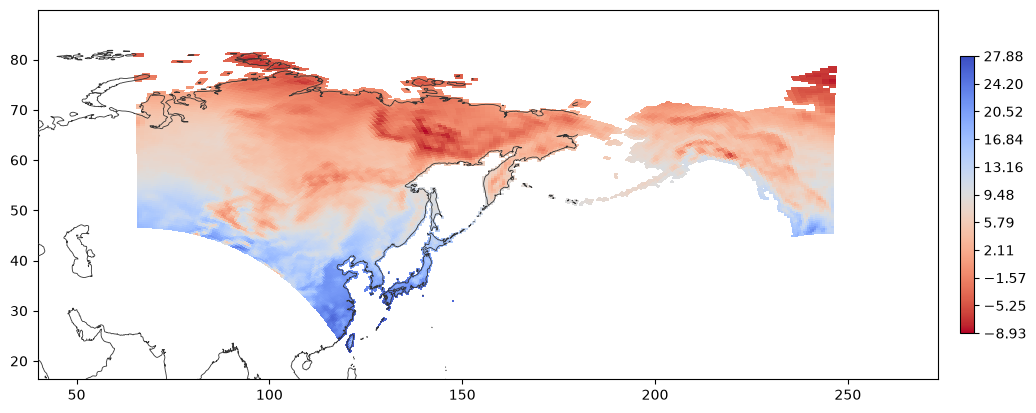

In [14]:
# This RASM grid wraps 0–360° longitude: its easternmost columns cross the 0/360
# "seam", which a flat pcolormesh can't draw (a seam-spanning cell smears across the
# whole width). Restrict to the seam-free western columns and plot on the variable's
# own 2-D curvilinear (xc, yc) coordinates.
xc = np.asarray(nc.get_variable('xc').read_array(), float)
yc = np.asarray(nc.get_variable('yc').read_array(), float)
tair = nc.get_variable('Tair').read_array()[0].astype(float)  # first time-step
tair[tair > 1e30] = (
    np.nan
)  # mask the fill value so it doesn't dominate the colour scale
lon_jump = np.abs(np.diff(np.where(xc > 1e30, np.nan, xc), axis=1)) > 100
cols = slice(0, int(np.argmax(lon_jump.any(axis=0))) or xc.shape[1])
patch = NetCDF.create_from_array(
    tair[:, cols],
    geo_ref=GeoReference(geo=(0, 1, 0, tair.shape[0], 0, -1), epsg=4326),
    variable_name='Tair',
)
glyph = patch.plot(
    variable='Tair', axes=CoordinateSpec(coords=(xc[:, cols], yc[:, cols]))
)
glyph.add_features("coastline", "50m", zorder=5)

**Retrieve the underlying data**

In [15]:
var = nc.get_variable('Tair')
data = var.read_array()
print('shape:', data.shape)
print(
    'min / mean / max:',
    float(np.nanmin(data)),
    float(np.nanmean(data)),
    float(np.nanmax(data)),
)

shape: (6, 205, 275)
min / mean / max: -45.14314058601594 5.372144206290461e+36 9.969209968386869e+36


**Add a variable** — derive a 2-D field and append it as a new variable

In [16]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d,
    geo_ref=GeoReference(geo=(0.0, 1.0, 0.0, 0.0, 0.0, -1.0), epsg=var.epsg or 4326),
    variable_name='Tair_slice0',
    path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'Tair_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['Tair', 'Tair_slice0', 'xc', 'yc']


**Remove a variable**

In [17]:
nc.remove_variable('Tair_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['Tair', 'xc', 'yc']


> **Polygon crop** — like the ROMS example above, this curvilinear grid is cropped by masking on its 2-D coordinates (cells whose centre is outside the polygon become no-data, then the grid is trimmed to the bounding window). The result keeps its 2-D coordinates and stays curvilinear.

**Save the container to a new NetCDF file**

In [18]:
out = work / 'saved.nc'
nc.to_file(out)
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True


## `none__5v__1d2-2d2-3d1__curv.nc`

Satellite IMAGE product with 2-D latitude/longitude and string metadata variables.

**Open the file and inspect the container**

In [19]:
nc = NetCDF.read_file(DATA / 'none__5v__1d2-2d2-3d1__curv.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\none__5v__1d2-2d2-3d1__curv.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [20]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (4):
    auditCount           size=1
    bands                size=5
    elems                size=640
    lines                size=480
  Variables (5):
    auditTrail dims=('/auditCount',) shape=(1,) dtype=unknown
    bands dims=('/bands',) shape=(5,) dtype=int32
    data dims=('/bands', '/lines', '/elems') shape=(5, 480, 640) dtype=float32 unit='unitless'
    latitude dims=('/lines', '/elems') shape=(480, 640) dtype=float32 unit='degrees'
    longitude dims=('/lines', '/elems') shape=(480, 640) dtype=float32 unit='degrees'
  Global attributes: 


**Global attributes**

In [21]:
nc.global_attributes

{}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

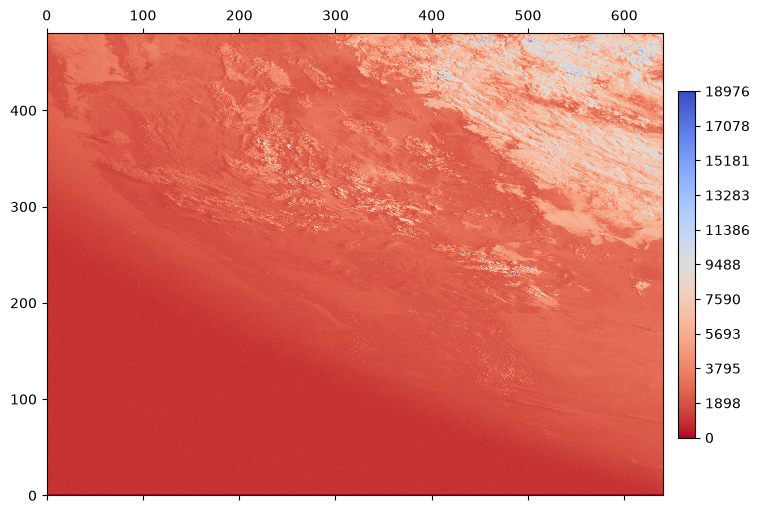

In [22]:
nc.plot(variable='data')

**Retrieve the underlying data**

In [23]:
var = nc.get_variable('data')
data = var.read_array()
print('shape:', data.shape)
print(
    'min / mean / max:',
    float(np.nanmin(data)),
    float(np.nanmean(data)),
    float(np.nanmax(data)),
)

shape: (5, 480, 640)
min / mean / max: 0.0 6867.66015625 23328.0


**Add a variable** — derive a 2-D field and append it as a new variable

In [24]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d,
    geo_ref=GeoReference(geo=(0.0, 1.0, 0.0, 0.0, 0.0, -1.0), epsg=var.epsg or 4326),
    variable_name='data_slice0',
    path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'data_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['auditTrail', 'data', 'data_slice0', 'latitude', 'longitude']


**Remove a variable**

In [25]:
nc.remove_variable('data_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['auditTrail', 'data', 'latitude', 'longitude']


> **Polygon crop** — like the ROMS example above, this curvilinear grid is cropped by masking on its 2-D coordinates (cells whose centre is outside the polygon become no-data, then the grid is trimmed to the bounding window). The result keeps its 2-D coordinates and stays curvilinear.

**Save the container to a new NetCDF file**

In [26]:
out = work / 'saved.nc'
nc.to_file(out)
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True
